In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np

In [105]:
type_names = [
    "No Optimisations",
    "Adjoint Differentiation",
    "Adjoint Diff + JIT Compiled"]

df = pd.read_pickle("qaoa_runtimes3.pkl")

# Adjust for the incorrect initial labelling of the file types
df["NewFileType"] = df.FileType.map({"No JIT": type_names[0], "No Adjoint": type_names[1], "No Batching": type_names[2]}).astype("category")

# Adjust for the offset or running "No Batching" without Adjoint Differentiation, which was a mistake in the original data collection
# Take the difference between the times on "No Optimisations" and "Adjoint Differentiation" on each qubit count, and add this difference to the "No Batching" times
for qubits in df['Qubits'].unique():
    no_opt_time = df[(df['Qubits'] == qubits) & (df['NewFileType'] == type_names[0])]['Time (s)'].values[0]
    adjoint_time = df[(df['Qubits'] == qubits) & (df['NewFileType'] == type_names[1])]['Time (s)'].values[0]
    time_diff = (adjoint_time - no_opt_time) / 3
    df.loc[(df['Qubits'] == qubits) & (df['NewFileType'] == type_names[2]), 'Time (s)'] += time_diff

# For our tests we used a smaller seed size 5 vs. 30 and a lessened epoch count 15 vs 150,
# We want to display the time it would've taken with the larger seed size and epoch count, so we will multiply the times by 60
df['Time (s)'] *= 60

# We have additive constants for the compilation time of the Baseline, Adjoint Differentiation, and JIT Compiled versions,

In [80]:
# There are the constants for the Baseline, Adjoint Differentiation, and JIT Compiled versions, which we will add to the times for the respective file types
# We have measured these constants by running the respective qubit counts with a seed size of 30 and epoch count of 150, however with the run_qaoa line commented out,
# so we are only measuring the time taken for the extra work done, loading the data, saving the data, and the compilation time for the JIT Compiled version and preprocessing

extra_time = pd.read_pickle("qaoa_30seed_constansts.pkl")
extra_time["NewFileType"] = extra_time.FileType.map({"No Adjoint": type_names[0], "No JIT": type_names[1], "No Batching": type_names[2]}).astype("category")

# Since we have multiple data points for each qubit count, we will take the mean of the times for each qubit count and file type and create a new dataframe with these mean times, which we will use for the curve fitting and extrapolation
time_constants = extra_time.groupby(['Qubits', 'NewFileType'])['Time (s)'].mean().reset_index()
time_constants

,Qubits,NewFileType,Time (s)
0,5,Adjoint Diff + JIT Compiled,1.932
1,5,Adjoint Differentiation,1.990
2,5,No Optimisations,1.942
3,6,Adjoint Diff + JIT Compiled,2.288
4,6,Adjoint Differentiation,2.176
5,6,No Optimisations,2.320
6,7,Adjoint Diff + JIT Compiled,2.664
7,7,Adjoint Differentiation,2.606
8,7,No Optimisations,2.710
9,8,Adjoint Diff + JIT Compiled,2.954


In [95]:
batched_runtimes = pd.read_pickle("qaoa_runtimes2.pkl")
batched_runtimes

,Qubits,Total Layers,Time (s)
0,5,32,227.97
1,5,32,231.10
2,5,32,227.01
3,5,32,234.55
4,5,32,134.32
...,...,...,...
95,14,32,3361.12
96,14,32,3256.56
97,14,32,2529.83
98,14,32,3232.14


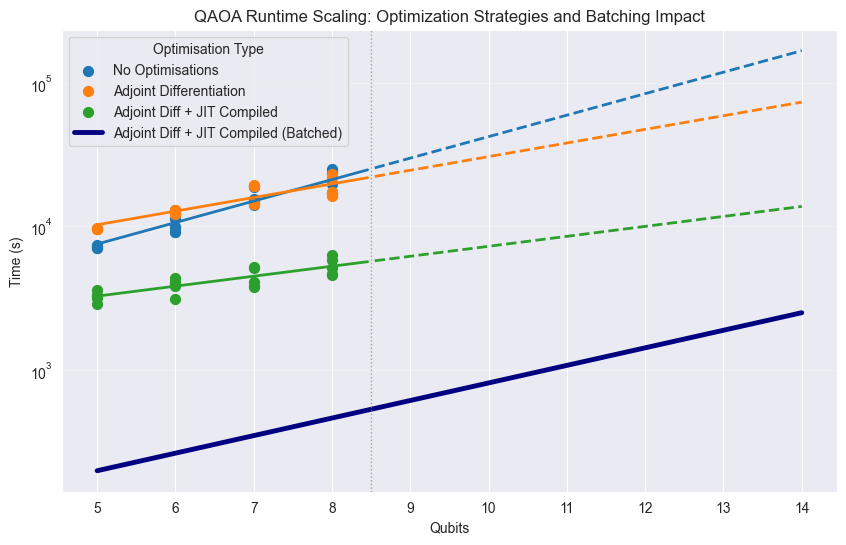

In [108]:
def exponential(x, a, b):
    return a * np.exp(b * x)

fig, ax = plt.subplots(figsize=(10, 6))

x_axis_vals = df['Qubits'].unique()
x_axis_vals.sort()

for name in type_names:
    subset = df[df['NewFileType'] == name]
    x_data = subset['Qubits'].values
    y_data = subset['Time (s)'].values.copy()  # Create a copy to avoid read-only error

    # Fit exponential curve
    popt, _ = curve_fit(exponential, x_data, y_data, p0=[1, 0.1], maxfev=10000)

    # Add the constants time for the datapoints 5-8 qubits from the time_constants dataframe
    for qubits in range(5, 9):
        const_time = time_constants[(time_constants['Qubits'] == qubits) & (time_constants['NewFileType'] == name)]['Time (s)'].values[0]
        y_data[x_data == qubits] += const_time

    # Plot data points
    line = ax.scatter(x_data, y_data, label=name, s=50)
    line_color = line.get_facecolors()[0]

    # Generate fitted curve and extrapolation and add the constants time for the fitted curve
    x_fit = np.linspace(x_data.min(), 14, 100)
    y_fit = exponential(x_fit, *popt).copy()

    # Add constant time based on integer qubit values from the fit
    for i, x_val in enumerate(x_fit):
        q_int = int(np.round(x_val))
        if q_int >= 5 and q_int <= 14:
            const_time = time_constants[(time_constants['Qubits'] == q_int) & (time_constants['NewFileType'] == name)]['Time (s)'].values
            if len(const_time) > 0:
                y_fit[i] += const_time[0]

    # Plot fitted curve up to qubit 8.5 (solid line)
    x_fit_data = x_fit[x_fit <= 8.5]
    y_fit_data = y_fit[x_fit <= 8.5]
    ax.plot(x_fit_data, y_fit_data, linewidth=2, color=line_color)

    # Plot extrapolated curve from 8.5 to 14 (dotted line)
    x_fit_extrap = x_fit[x_fit >= 8.5]
    y_fit_extrap = y_fit[x_fit >= 8.5]
    ax.plot(x_fit_extrap, y_fit_extrap, linewidth=2, linestyle='--', color=line_color)

# Plot batched runtimes (Adjoint Diff + JIT Compiled with batching)
x_data = batched_runtimes['Qubits'].values
y_data = batched_runtimes['Time (s)'].values

# Fit exponential curve
popt, _ = curve_fit(exponential, x_data, y_data, p0=[1, 0.1], maxfev=10000)

# Generate fitted curve (solid throughout, no extrapolation needed)
x_fit = np.linspace(x_data.min(), x_data.max(), 100)
y_fit = exponential(x_fit, *popt)

# Plot as solid line with different style to distinguish from non-batched
ax.plot(x_fit, y_fit, linewidth=3.5, linestyle='-', color='navy', label='Adjoint Diff + JIT Compiled (Batched)')

# Add vertical line between 8 and 9
ax.axvline(x=8.5, linestyle=':', color='gray', linewidth=1, alpha=0.7)

# sns.regplot(df, x="Qubits", y="Time (s)", ax=ax)
ax.set_yscale('log')
ax.set_xlabel('Qubits')
ax.set_ylabel('Time (s)')
ax.set_xticks(range(int(x_axis_vals.min()), 15))
ax.legend(title="Optimisation Type")
ax.grid(True, alpha=0.3, axis='y')
plt.title("QAOA Runtime Scaling: Optimization Strategies and Batching Impact")

plt.savefig(f"plots/runtimes_comparison_exrapolated.svg", dpi=300, bbox_inches='tight')

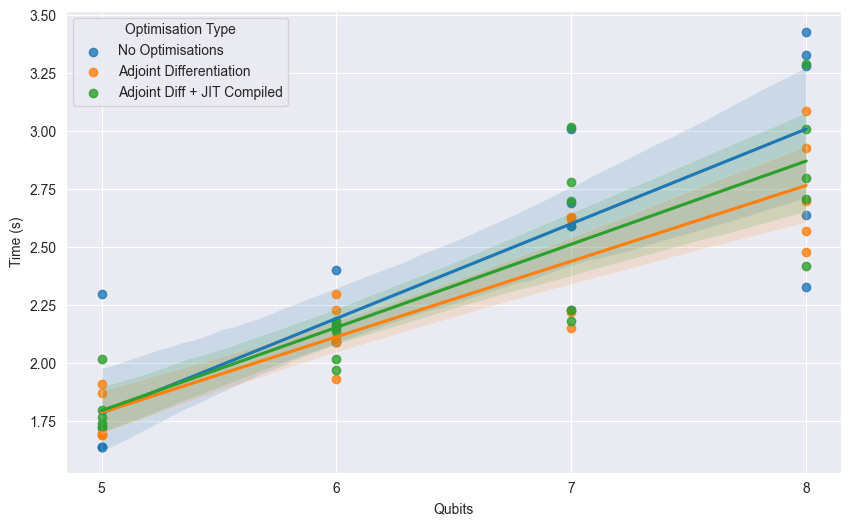

In [78]:


fig, ax = plt.subplots(figsize=(10, 6))

x_axis_vals = df2['Qubits'].unique()
x_axis_vals.sort()

for name in type_names:
    subset = df2[df2['NewFileType'] == name]
    sns.regplot(subset, x="Qubits", y="Time (s)", ax=ax, label=name)

# sns.regplot(df, x="Qubits", y="Time (s)", ax=ax)
ax.set_xticks(x_axis_vals)
# ax.set_yscale('log')
ax.legend(title="Optimisation Type")

plt.savefig(f"plots/runtimes_comparison2.svg", dpi=300, bbox_inches='tight')